# Assignment 1

## Part 1

### *Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025.*

In [12]:
import io
import urllib
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/denisababeii/assignment1_social_data/main/data/selected.csv.zip"

# Download the zipped file
with urllib.request.urlopen(url) as response:
    data = response.read()

# Extract and read the CSV from the zip file
with zipfile.ZipFile(io.BytesIO(data)) as zip_file:
    # List files in the zip to see what's inside
    print("Files in zip:", zip_file.namelist())
    
    # Read the CSV file (adjust filename if needed)
    csv_filename = zip_file.namelist()[0]  # Gets the first file in the zip
    with zip_file.open(csv_filename) as csv_file:
        df = pd.read_csv(csv_file)

# Save it locally
df.to_csv('selected.csv', index=False)
print("✓ File saved as 'selected.csv'")
print(f"Shape: {df.shape}")
df.head()

Files in zip: ['selected.csv', '__MACOSX/._selected.csv']
✓ File saved as 'selected.csv'
Shape: (480796, 7)


,Incident Date,Incident Time,Incident Year,Incident Category,Police District,Latitude,Longitude
0,2016-03-03,19:30,2016,MOTOR VEHICLE THEFT,TARAVAL,37.707968,-122.463545
1,2014-12-26,15:30,2014,MOTOR VEHICLE THEFT,MISSION,37.755900,-122.424435
2,2012-05-04,12:00,2012,ROBBERY,INGLESIDE,37.708311,-122.420084
3,2013-11-02,10:06,2013,ARSON,PARK,37.751998,-122.459032
4,2016-01-29,10:09,2016,WARRANT,SOUTHERN,37.776930,-122.410809


In [ ]:
# Load the dataset
data = pd.read_csv("selected.csv")
df = pd.DataFrame(data)
# Convert 'Incident Date' to datetime, coercing errors to NaT
df["Incident Date"] = pd.to_datetime(df["Incident Date"], errors='coerce')

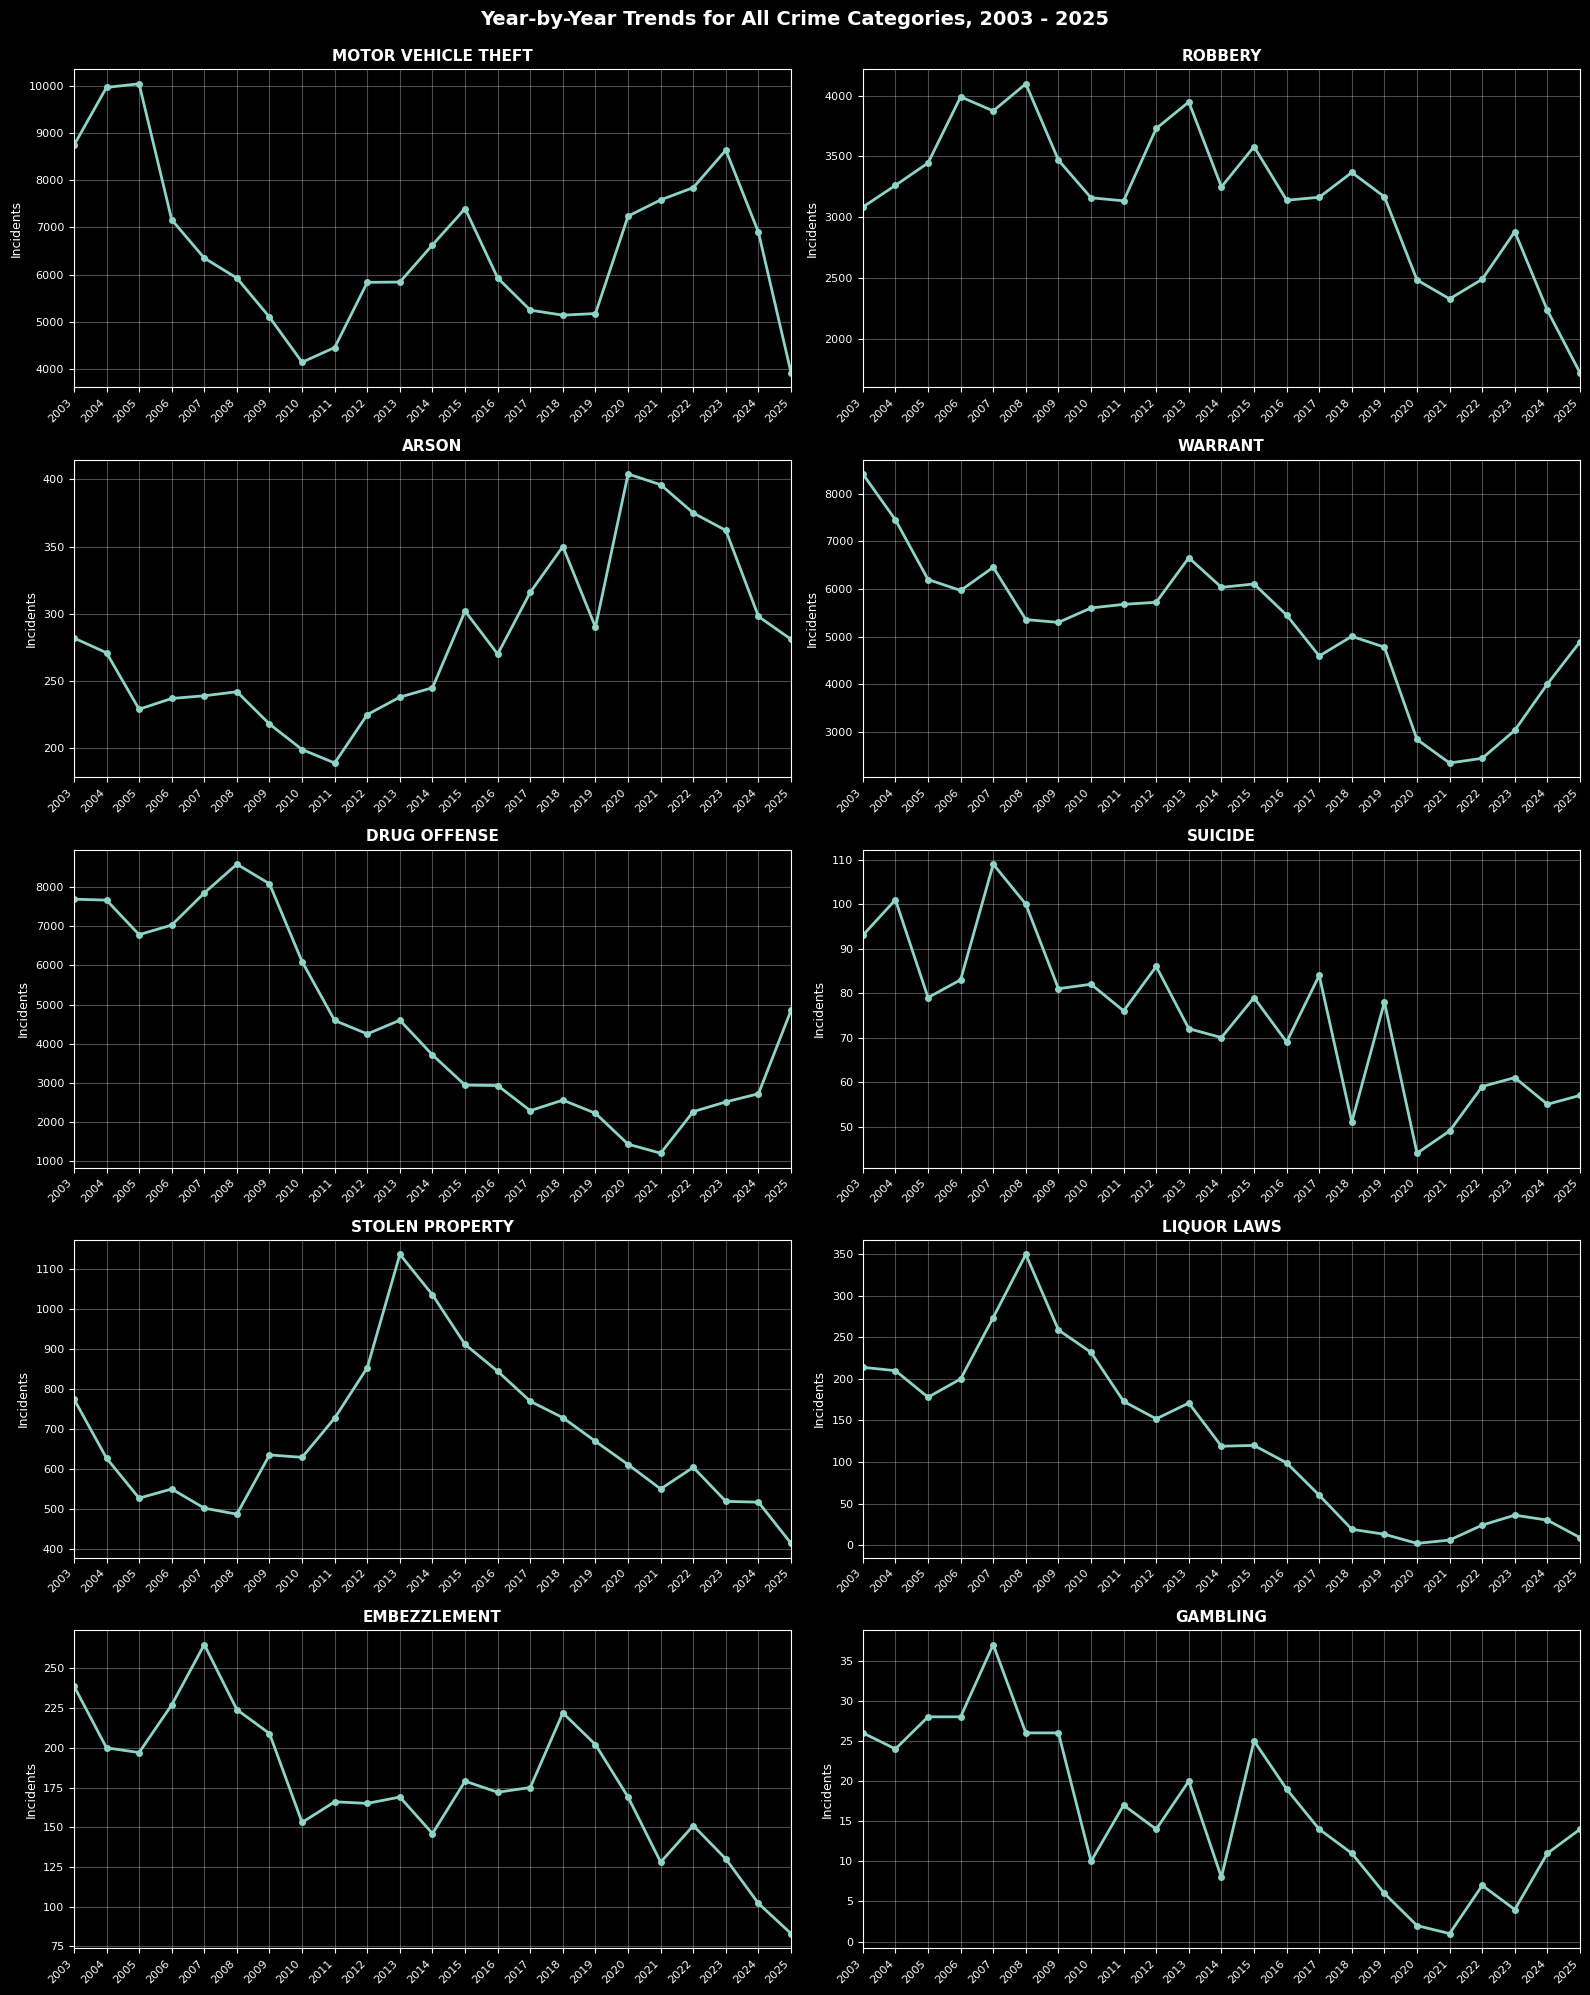

In [ ]:
categories = df["Incident Category"].unique()
# Number of unique categories
n_categories = len(categories)
cols = 2
rows = math.ceil(n_categories / cols)
# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()
# Loop through each category and plot the yearly trend
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    category_data = df[df["Incident Category"] == category]
    yearly_counts = category_data["Incident Year"].value_counts().sort_index()
    
    ax.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=4)
    
    years_list = list(range(2003, 2026))
    ax.set_xticks(years_list)
    
    ax.set_xticklabels(years_list, rotation=45, ha='right')

    ax.set_xlim(2003, 2025)
    
    ax.set_title(category, fontsize=11, fontweight='bold')
    ax.set_ylabel("Incidents", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

for idx in range(n_categories, len(axes)):
    axes[idx].axis('off')

plt.suptitle("Year-by-Year Trends for All Crime Categories, " + str(df["Incident Year"].min()) + " - " + str(df["Incident Year"].max()), fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The figure above shows year by year trends for the focus crimes chosen (MOTOR VEHICLE THEFT, ROBBERY, ARSON, WARRANT, DRUG OFFENSE, SUICIDE, STOLEN PROPERTY, LIQUOR LAWS, EMBEZZLEMENT, GAMBLING). Year by year trends are shown for the period 2003-2025. 

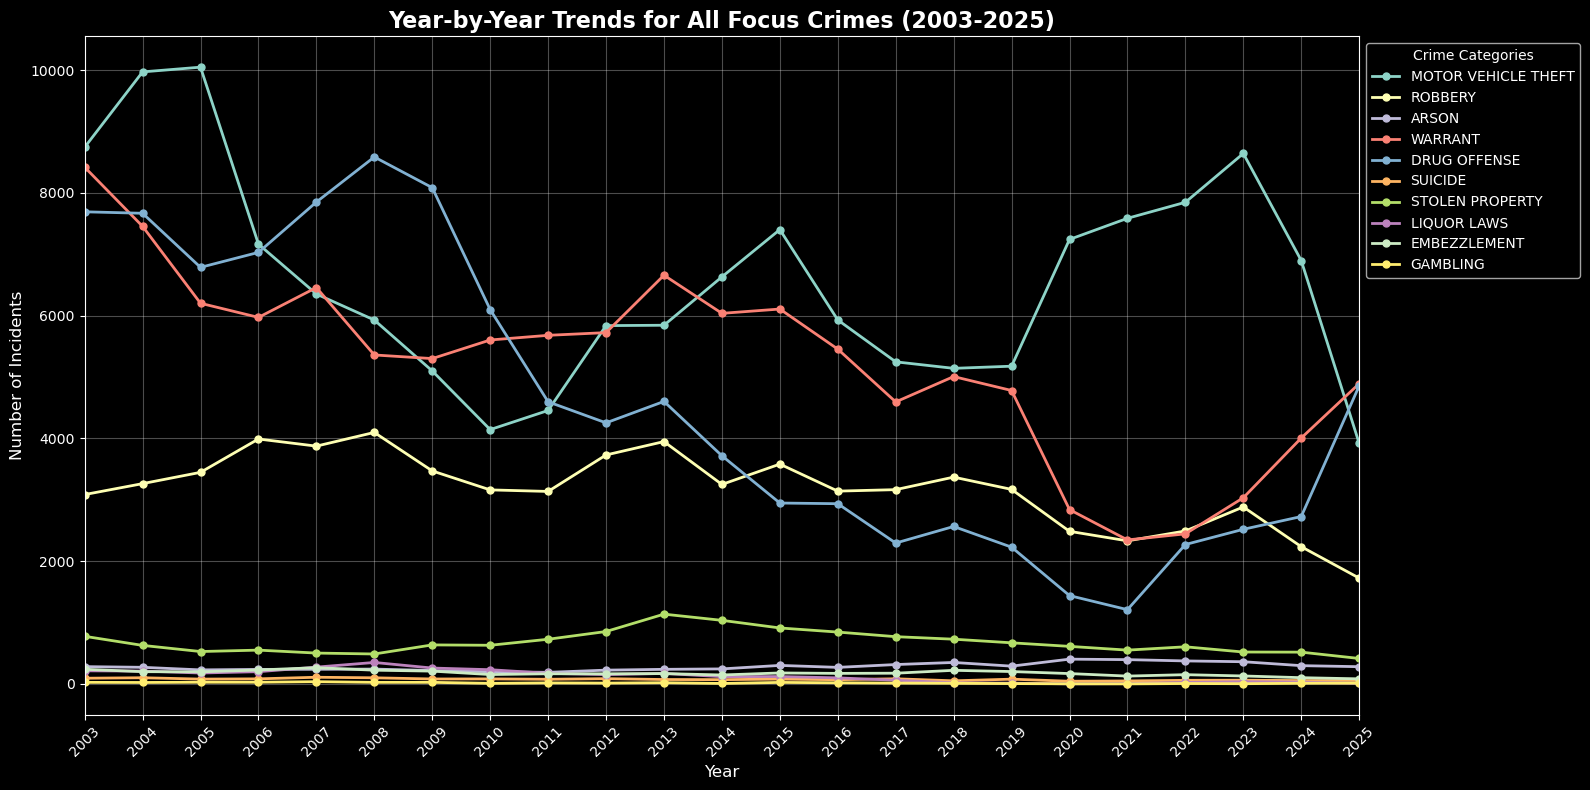

In [ ]:
plt.figure(figsize=(16, 8))
all_years = list(range(2003, 2026))
# Loop through each category and plot the yearly trend on the same graph
for category in categories:
    category_data = df[df["Incident Category"] == category]
    yearly_counts = category_data["Incident Year"].value_counts().reindex(all_years, fill_value=0).sort_index()
    plt.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=5, label=category)

plt.xticks(all_years, rotation=45)
plt.xlim(2003, 2025)
plt.title("Year-by-Year Trends for All Focus Crimes (2003-2025)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Crime Categories", loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.tight_layout()
plt.show()

The figure above shows year by year trends for the focus crimes chosen (MOTOR VEHICLE THEFT, ROBBERY, ARSON, WARRANT, DRUG OFFENSE, SUICIDE, STOLEN PROPERTY, LIQUOR LAWS, EMBEZZLEMENT, GAMBLING). Year by year trends are shown for the period 2003-2025. 

### *Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.*

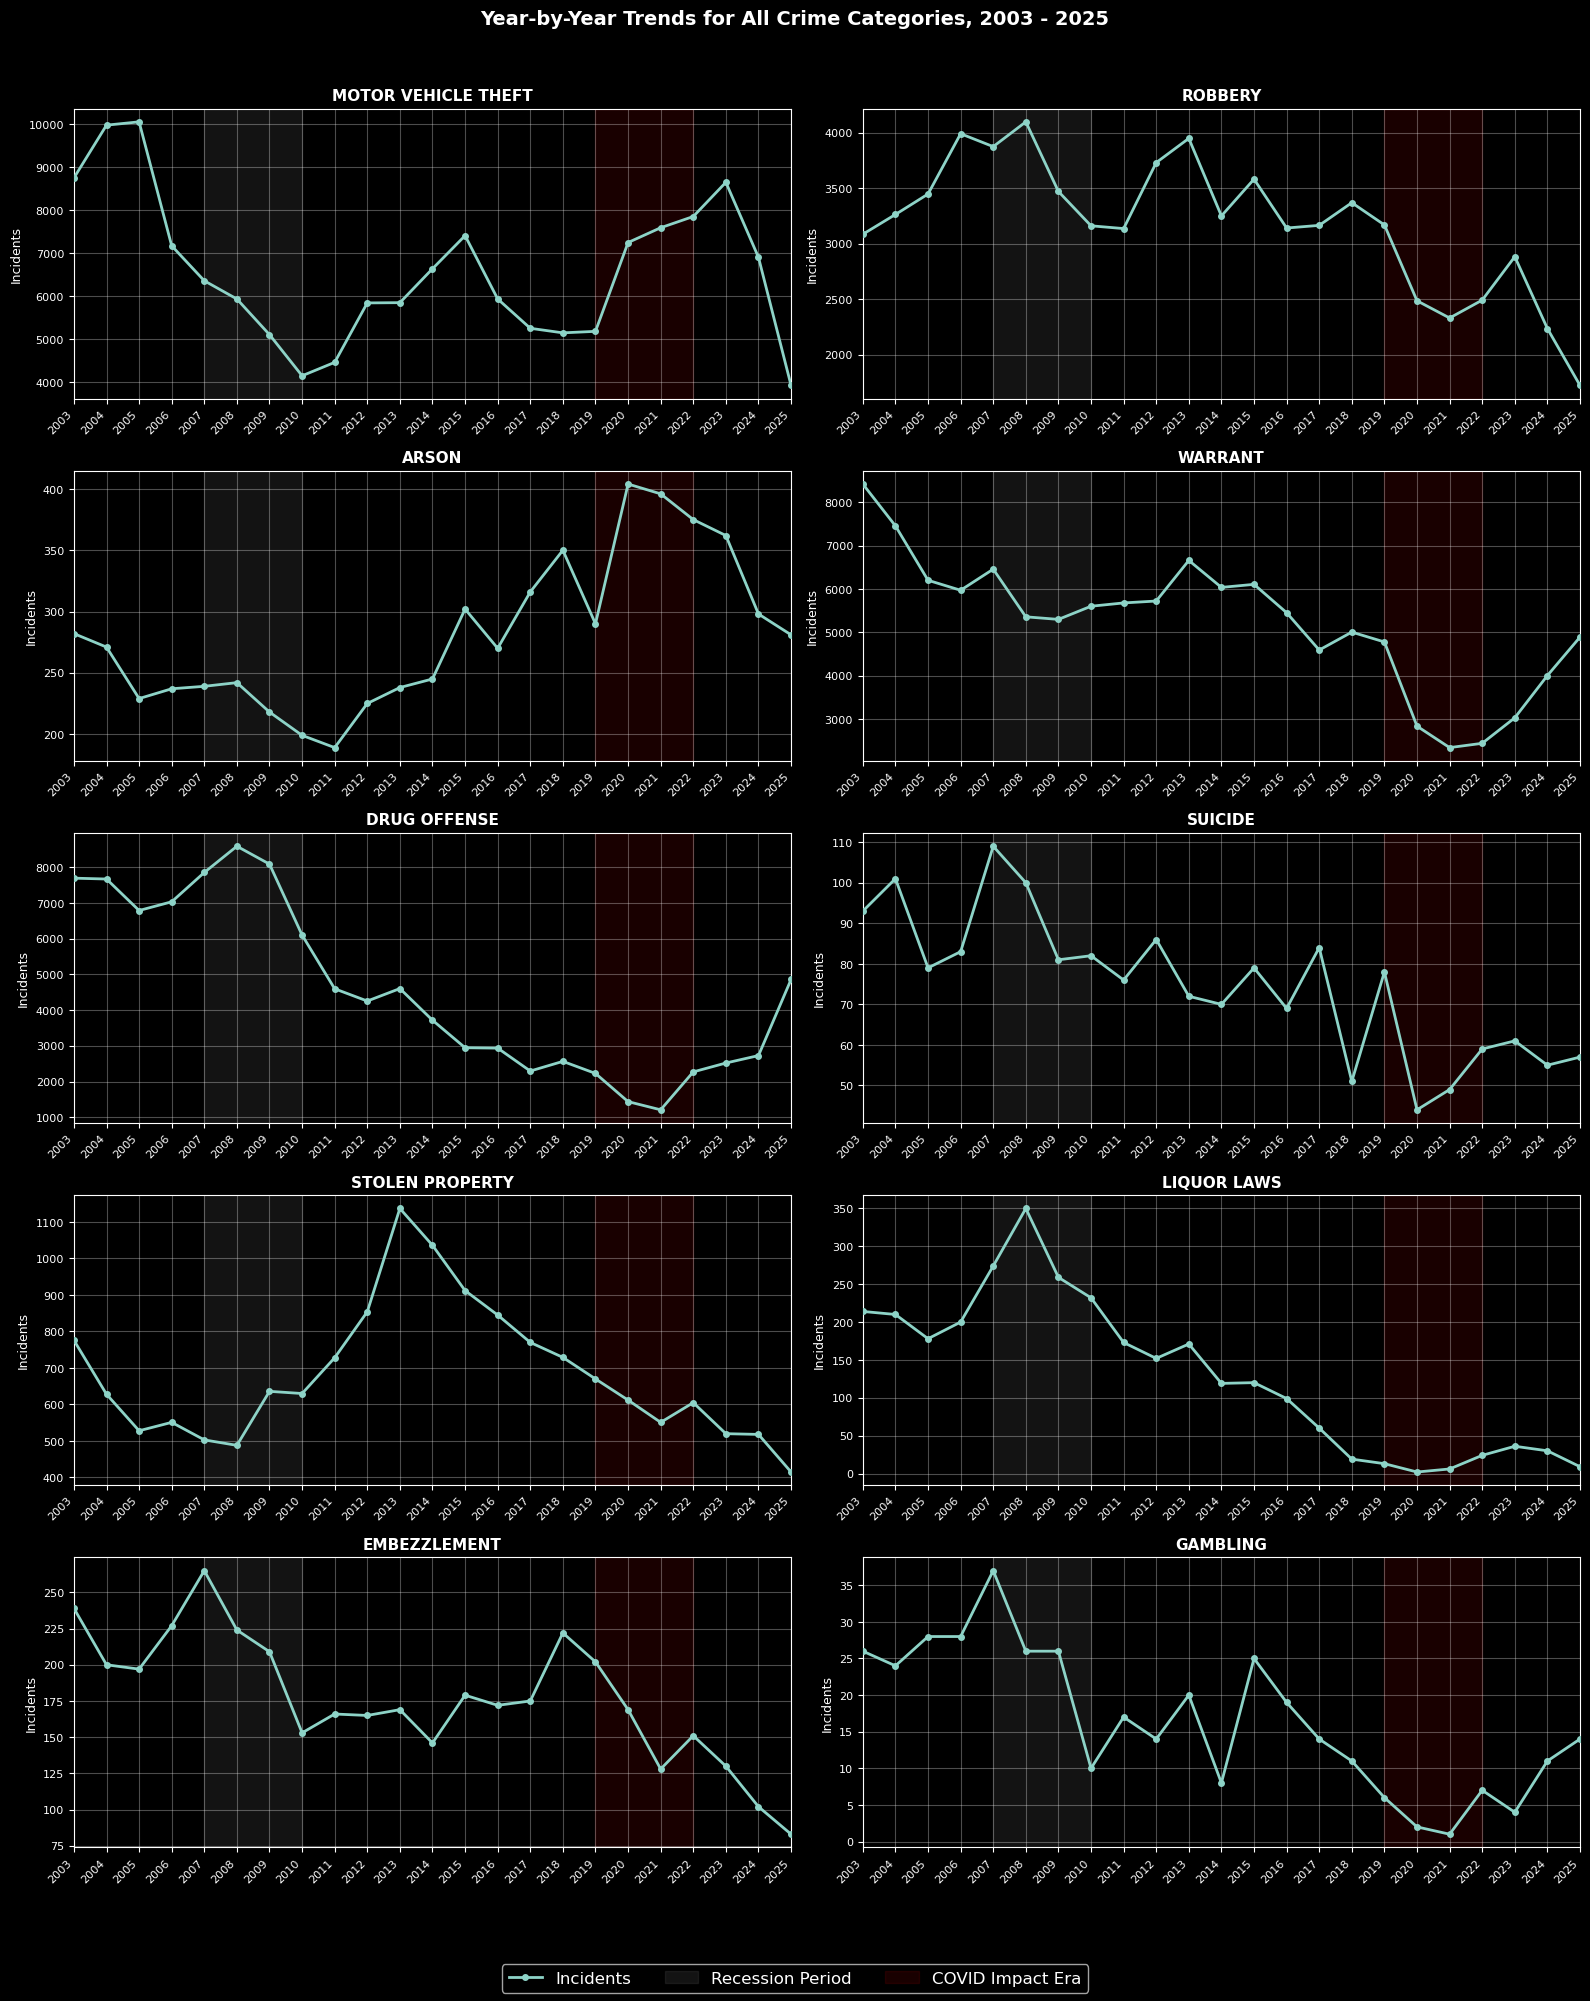

In [ ]:
cols = 2
rows = math.ceil(n_categories / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

years_list = list(range(2003, 2026))

# Loop through each category and plot the yearly trend with recession and COVID-19 impact periods highlighted
for idx, category in enumerate(categories):
    ax = axes[idx]
    
    category_data = df[df["Incident Category"] == category]
    yearly_counts = category_data["Incident Year"].value_counts().sort_index()

    ax.plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=4, label='Incidents', zorder=3)

    ax.axvspan(2007, 2010, color='gray', alpha=0.15, label='Recession Period') # Financial Crisis: 2007 (Before) to 2010 (After/Recovery)
    ax.axvspan(2019, 2022, color='red', alpha=0.1, label='COVID Impact Era')   # COVID-19: 2019 (Before) to 2022 (Recovery phase)
    
    ax.set_xticks(years_list)
    ax.set_xticklabels(years_list, rotation=45, ha='right')
    ax.set_xlim(2003, 2025)
    ax.set_title(category, fontsize=11, fontweight='bold')
    ax.set_ylabel("Incidents", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
    
for idx in range(n_categories, len(axes)):
    axes[idx].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12)

plt.suptitle("Year-by-Year Trends for All Crime Categories, " + str(df["Incident Year"].min()) + " - " + str(df["Incident Year"].max()), fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0.05, 1, 0.98]) 
plt.show()

The figure above shows year-by-year trends for the focus crimes chosen (MOTOR VEHICLE THEFT, ROBBERY, ARSON, WARRANT, DRUG OFFENSE, SUICIDE, STOLEN PROPERTY, LIQUOR LAWS, EMBEZZLEMENT, GAMBLING).
Year-by-year trends are shown for the period 2003–2025. 

Two historical time periods are highlighted in the figure:
1) Financial Crisis: 2007 (Before) to 2010 (After/Recovery)
2) COVID-19: 2019 (Before) to 2022 (Recovery phase)


The grey-shaded area illustrates how crime patterns shifted during a period of severe global economic stress.

* Observations: While MOTOR VEHICLE THEFT and EMBEZZLEMENT declined significantly during this period, LIQUOR LAWS and DRUG OFFENCE increased and peaked between 2008 and 2009.

* Explanation: Economic downturns often lead to increased activity in “underground” economies or substance-related incidents as unemployment and financial hardship rise. This “stress-response” theory explains the peak in LIQUOR LAWS and DRUG OFFENCE during the crisis.  Conversely, the decline in MOTOR VEHICLE THEFT likely reflects reduced mobility and fewer high-value targets on the streets as consumer spending and vehicle usage changed during the recession.

Almost every subplot highlights the dramatic shock caused by the pandemic, particularly starting in 2020.

* Observations: Categories like ROBBERY, WARRANT, DRUG OFFENCE, and LIQUOR LAWS show sharp declines or deep troughs during the red-shaded window. ARSON, however, reaches a historical peak during the same period.

* Explanation: The “stay at home” orders and widespread closure of the hospitality industry (bars and nightclubs) dramatically changed the urban landscape. Many crimes are “opportunity-based” and require public interaction or density.  With fewer pedestrians and closed businesses, the physical opportunity for street-level robbery and liquor violations dropped. However, the rise in ARSON suggests that while interpersonal crimes fell due to social isolation, property-related acts of social frustration or opportunism in empty areas may have increased.


## Part 2

### *For each police district in your dataset, compute the conditional crime profile*

 $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

In [ ]:
# Filter the DataFrame to include only rows where 'Police District' is one of the official districts
official_districts = [
    'NORTHERN', 'PARK', 'INGLESIDE', 'BAYVIEW', 'RICHMOND', 
    'CENTRAL', 'TARAVAL', 'TENDERLOIN', 'MISSION', 'SOUTHERN'
]
df_clean = df[df['Police District'].isin(official_districts)].copy()

In [18]:
# Compute the overall probability of each crime category in the cleaned dataset
p_crime = df_clean['Incident Category'].value_counts(normalize=True)
print(p_crime)

Incident Category
MOTOR VEHICLE THEFT    0.314041
WARRANT                0.250504
DRUG OFFENSE           0.218630
ROBBERY                0.152023
STOLEN PROPERTY        0.032405
ARSON                  0.013452
EMBEZZLEMENT           0.008430
LIQUOR LAWS            0.006148
SUICIDE                0.003580
GAMBLING               0.000788
Name: proportion, dtype: float64


In [19]:
# Group by District AND Category, find the proportion of each crime within each district
p_crime_given_district = df_clean.groupby('Police District')['Incident Category'].value_counts(normalize=True).unstack(fill_value=0)
# Calculate the ratio of P(crime | district) to P(crime) for each crime category and district
r = p_crime_given_district / p_crime
print(r)

Incident Category     ARSON  DRUG OFFENSE  EMBEZZLEMENT  GAMBLING  \
Police District                                                     
BAYVIEW            1.976017      0.685793      1.028015  1.339233   
CENTRAL            1.249099      0.522831      1.954976  2.221929   
INGLESIDE          1.054379      0.417693      0.583537  1.708126   
MISSION            0.826732      1.080722      0.735978  0.825405   
NORTHERN           1.057754      0.809198      0.958282  0.568329   
PARK               0.742899      0.849614      0.661913  0.105719   
RICHMOND           1.314189      0.425890      1.039255  0.799123   
SOUTHERN           0.797974      1.131948      1.337155  0.682192   
TARAVAL            1.183067      0.419649      1.269473  1.044978   
TENDERLOIN         0.395111      2.191338      0.696026  0.823685   

Incident Category  LIQUOR LAWS  MOTOR VEHICLE THEFT   ROBBERY  \
Police District                                                 
BAYVIEW               0.720122           

### *Visualize these ratios in a way that makes it easy to compare across both districts and crime types.*

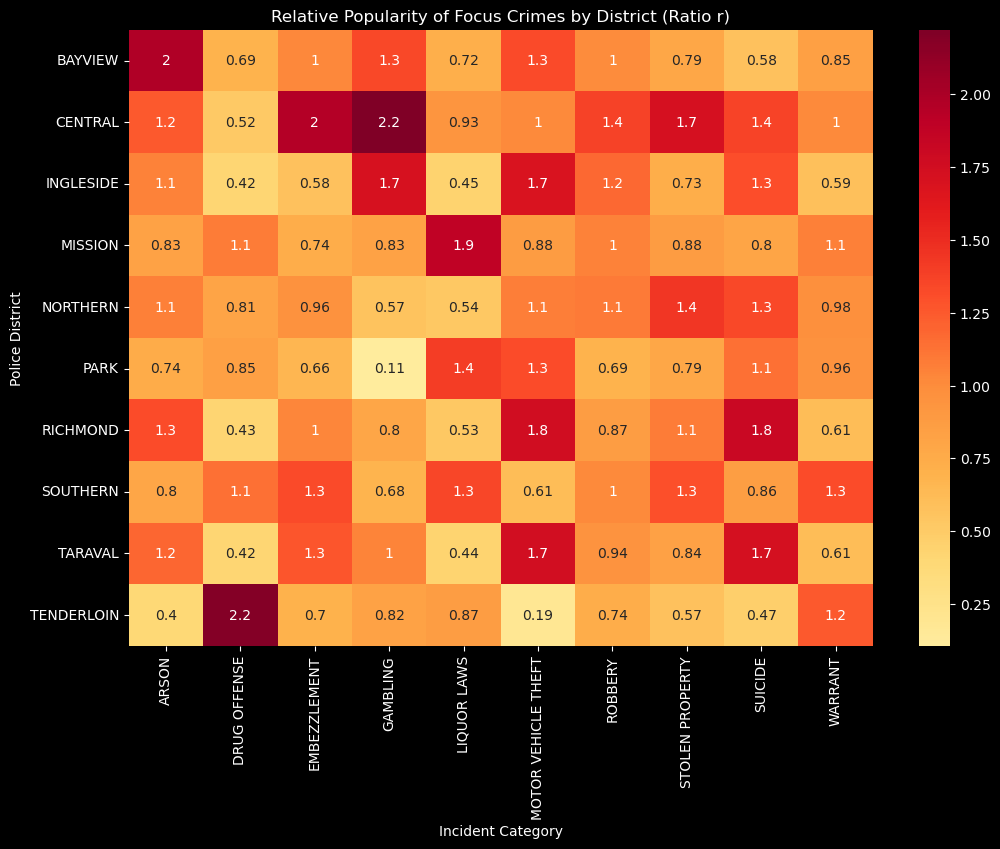

In [ ]:
plt.figure(figsize=(12, 8))
# Create a heatmap of the ratio r 
sns.heatmap(r, annot=True, cmap="YlOrRd", center=1)
plt.title("Relative Popularity of Focus Crimes by District (Ratio r)")
plt.show()

The figure above illustrates the relative popularity of focus crimes across the ten different Police Districts in San Francisco for the period 2003–2025. The values represent the ratio (r), which measures how prevalent a crime category is in a specific district compared to the city-wide average. A ratio of r=1 indicates that the crime occurs at the expected average rate, while r>1 signifies a higher concentration and r<1 signifies a lower concentration of that incident category within the district.

### *Pick one district whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?*

By examining the relative popularity ratios (r), there are two districts that serve as opposites in terms of their criminal signatures: the Tenderloin and the Central District. While they are geographically close, their socio-economic and urban environments create very different data profiles.

The Tenderloin stands out as a significant statistical outlier, defined by high-visibility street activity and a lack of traditional property targets.
* Key Observations:
    * Drug Offences (r=2.2): This is the highest ratio in the city, indicating that drug-related incidents are more than twice as likely to occur here relative to the city average.
    * Motor Vehicle Theft (r=0.19): Tenderloin has the lowest relative frequency of vehicle theft in San Francisco.
* Explanation and Factors:
    * Geographic Density: The area’s high population density make it a frequent location for street-level activity. This makes crimes like drug deals very easy for the police to see and report.
    * Urban Layout: For car theft, thieves typically target quiet residential areas with a low crime rate, such as Richmond (r=1.75). The presence of a large number of people in the Tenderloin makes it an unsuitable location for a thief to spend time breaking into a vehicle.

The Central District is the city’s financial and tourism hub. Its profile is characterised by high-value targets.
* Key Observations:
    * Gambling (r=2.2) and Embezzlement (r=2): Central holds the city’s highest ratios for these categories, reflecting its role as a financial and cultural hub.
    * Stolen Property (r=1.7) and Robbery (r=1.4): These ratios are significantly elevated compared to residential districts.
    * Drug Offences (r=0.52): Despite high foot traffic, drug-related incidents are nearly 50% below the city average.
* Explanation and Factors:
    * Economic Infrastructure: The peak in embezzlement is directly linked to the concentration of banking and corporate headquarters in the Financial District. These are ‘crimes of access’ that require a corporate environment to exist.
    * Tourist hubs attract a large number of visitors carrying expensive electronics and cash, creating a high-risk environment for robbery and theft.
    * The low drug offence ratio is likely a result of intensive security in the city centre. This often pushes street-level drug activity out of Central and into the neighbouring Tenderloin.